## Ligand Contribution Check via Reverse Score-Binder

This notebook estimates how much a ligand contributes to MaSIF match quality for a given `(target, matched_protein)` pair.

### Core idea
For a hit from MaSIF search, compare reverse-mode scores in two conditions:
1. **With ligand**: score `matched_protein` against the original `target`.
2. **Without ligand**: score the same `matched_protein` against `target-no-ligand`.

A large positive delta (`with_ligand - no_ligand`) suggests ligand-dependent matching.

### Why reverse mode?
The CSV row stores a transform that places the matched protein in the target frame. To reverse the query direction, we invert that transform so we can score from `matched_protein` back onto the target side consistently.

### What this notebook does
1. Load one row from the search results CSV.
2. Reproduce row-like scores using `masif_search.py --score_binder --transform`.
3. Invert the stored transform and run reverse scoring.
4. Preprocess `target-no-ligand`.
5. Run reverse scoring again against `target-no-ligand`.
6. Compute:
   - `delta_nn_score`
   - `delta_desc_dist_score`
   - `delta_mean_desc_dist_score`

### Assumptions
- `masif_search.py` supports `--score_binder` and `--transform`.
- `flattened_transform` in the CSV is in row-major 4x4 format.
- `target-no-ligand` preprocessing exists (or is generated in this notebook) before delta calculation.

In [1]:
# --------------------- Define key paths -----------------------
import os
import sys
import pandas as pd
import numpy as np

# Path to tricompelx-design repo
tricomplex_design_repo = "/scratch/ymeng/masif-neosurf-af2/tricomplex-design_Meng"

# Paths to MaSIF-Neosurf search results
proj_name = "8VLB_A_3JF_A"
search_af2_grid_dir = os.path.join(tricomplex_design_repo, "search_af2_grid")
search_results_csv = os.path.join(tricomplex_design_repo, "results", "8VLB_A_3JF_A", "8VLB_A_3JF_A_deduplicated.csv")

# Paths to relevant slurm scripts (tricomplex-design repo)
slurm_dir = os.path.join(tricomplex_design_repo, "scripts", "slurm")
slurm_config_path = os.path.join(slurm_dir, "config.sh")

# Path to masif-neosurf repo
masif_neosurf_repo = "/scratch/ymeng/masif-neosurf-af2"

# ---- Load variables defined in config.sh ----
with open(slurm_config_path, "r") as f:
    slurm_config_content = f.read()

# Convert slurm_config_content into python variables
slurm_config = {}
for line in slurm_config_content.split("\n"):
    line = line.strip()
    # Skip comments and blank lines
    if not line or line.startswith('#'):
        continue
    if "=" in line:
        key, value = line.split("=", 1)
        slurm_config[key.strip()] = value.strip()
# ------------------------------------------------

# Preprocessing directories
target_preprocessing_dir = os.path.join(search_af2_grid_dir, proj_name, "preprocessing")
matched_preprocessing_dir = slurm_config["DATA_ROOT"]

# Debug directory for visualizing the patches used for scoring
site_debug_dir = "/scratch/ymeng/masif-neosurf-af2/notebooks/site_debug"

___
### Step 1 - End-to-End Scoring Logic (Forward + Reverse + Delta)

This notebook uses `masif_search.py --score_binder --transform` in three stages to estimate ligand dependence.

Required input:
- MaSIF-Neosurf results .csv file
- Preprocessing directory of both `target` and `target_no_ligand`

1. Forward query (sanity check against CSV row)
    - Inputs from one CSV row: `target`, `target_vix`, `matched_protein`, `flattened_transform`.
    - Run score-only mode with:
      - query = `target` at `target_vix`
      - binder = `matched_protein` transformed by `flattened_transform`
    - Purpose: verify we recover row-like scores (`nn_score`, `desc_dist_score`, `mean_desc_dist_score`).

2.  Reverse query (pose-preserving direction swap)
    - Swap roles to score from the matched side back to target:
      - query = `matched_protein` at `matched_vix`
      - binder = `target`
    - Use the inverse transform `invert_transform(flattened_transform)` so the relative pose is preserved after swapping query/binder roles.

3. Delta computation with and without ligand
    - Repeat the same reverse query twice:
      - binder = `target` (with ligand)
      - binder = `target-no-ligand`
    - `compute_delta_scores(...)` automates both runs and returns:
      - prefixed metrics for each condition (`rev_with_ligand_*`, `rev_no_ligand_*`)
      - delta values:
        - `delta_nn_score`
        - `delta_desc_dist_score`
        - `delta_mean_desc_dist_score`


Note: In score-only mode, binder center (`binder_vix`) is chosen by nearest transformed point, while CSV `matched_vix` comes from search-mode descriptor/alignment flow. Therefore `binder_vix` can differ and scores can be close but not identical.

Interpretation guideline: Large positive deltas suggest the matched interaction depends on ligand-associated target features.

In [2]:
# Read search_results_csv and get a key row for testing
df_results = pd.read_csv(search_results_csv)

# Get the row whose uniprot_accn is Q16878 (positive control)
row = df_results[df_results['uniprot_accn'] == 'Q16878'].iloc[0]

pd.set_option('display.max_rows', None)
row

target                                                                     8VLB_A
target_path                     /scratch/ymeng/tricomplex-design_Meng/search_a...
target_site                                                                site_9
target_vix                                                                   2489
matched_protein                                                   Q16878-F1-nD1_A
matched_patch_id                                                               45
matched_protein_path            /scratch/ymeng/tricomplex-design_Meng/search_a...
score                                                                      0.9897
desc_dist_score                                                         30.378494
clashing_ca                                                                     0
clashing_heavy                                                                  0
matched_vix                                                                  2636
desc_dist       

In [17]:
# Reproduce a row score with score-only mode using the saved rigid transform
# (flattened_transform comes from process_search_outputs.py)

import subprocess

# Function to run masif_search.py with score_binder mode
def run_score_binder(
    target_preprocessing_dir,
    target_name,
    target_vix,
    matched_preprocessing_dir,
    matched_protein,
    flattened_transform,
    masif_neosurf_repo,
    site_debug_dir=None
):
    import subprocess

    # Construct the base command (as a list)
    cmd = [
        "python",
        f"{masif_neosurf_repo}/masif_search.py",
        # matched_protein args
        "--database", str(matched_preprocessing_dir),
        "--score_binder", str(matched_protein),
        "--transform", str(flattened_transform),
        # target args
        "--target_dir", str(target_preprocessing_dir),
        "--target", str(target_name),
        "--site_vix", str(target_vix),
    ]
    # If site_debug_dir is specified, append the argument in correct form
    if site_debug_dir is not None:
        cmd += ["--site_debug", str(site_debug_dir)]

    # --- Python 3.6 compatibility: do not use capture_output argument ---
    # Instead, use stdout=subprocess.PIPE, stderr=subprocess.PIPE
    res = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True, check=True)
    print(res.stdout)

    # Parse the final score line into a python dict
    score_line = [line for line in res.stdout.splitlines() if line.startswith("query_name:")][-1]
    score_dict = {}
    for item in score_line.split(", "):
        key, value = item.split(": ", 1)
        try:
            if any(c in value for c in [".", "e", "E"]):
                score_dict[key] = float(value)
            else:
                score_dict[key] = int(value)
        except ValueError:
            score_dict[key] = value

    return score_dict

# Example usage:
# score_dict = run_score_binder(
#     target_preprocessing_dir,
#     target_name,
#     target_vix,
#     matched_preprocessing_dir,
#     matched_protein,
#     flattened_transform,
#     masif_neosurf_repo,
# )
# score_dict


In [ ]:
# Try a different row
row = df_results.iloc[0]
row

#### Step 1.1 - Reverse Scoring Setup

In this section, we invert `flattened_transform` and swap query/binder roles:
- Query: `matched_protein` at `matched_vix`
- Binder: original `target` (or later `target-no-ligand`)

This keeps the same relative pose while evaluating the target side in reverse mode.

In [ ]:
# target and matched_protein details from this row
target_name = row['target']
target_vix = row['target_vix']
matched_protein = row['matched_protein']
matched_protein_vix = row['matched_vix']
flattened_transform = row['flattened_transform']

# Print the expected arguments and values
print(f"query target_preprocessing_dir: {target_preprocessing_dir}")
print(f"query target_name: {target_name}")
print(f"query target_vix: {target_vix}")
print(f"")
print(f"query matched_preprocessing_dir: {matched_preprocessing_dir}")
print(f"query matched_protein: {matched_protein}")
print(f"query flattened_transform: {flattened_transform}")
print(f"")
print(f"Expected CSV score:                {row['score']:.4f}")
print(f"Expected CSV desc_dist_score:      {row['desc_dist_score']:.6f}")
print(f"Expected CSV mean_desc_dist_score: {row['mean_desc_dist_score']:.6f}")

# Example usage:
score_dict = run_score_binder(
    target_preprocessing_dir,
    target_name,
    target_vix,
    matched_preprocessing_dir,
    matched_protein,
    flattened_transform,
    masif_neosurf_repo,
    site_debug_dir = None
)
score_dict

query target_preprocessing_dir: /scratch/ymeng/masif-neosurf-af2/tricomplex-design_Meng/search_af2_grid/8VLB_A_3JF_A/preprocessing
query target_name: 8VLB_A
query target_vix: 2489

query matched_preprocessing_dir: /work/lpdi/users/diazrovi/domaindome/20260221-AFDBv6_domaindome_DPAM_masif/dpam_domaindome_masif_db
query matched_protein: Q16878-F1-nD1_A
query flattened_transform: 0.5376486240280203,-0.8390313674815559,0.08342854105644064,99.0337329379552,-0.8199522708295995,-0.4972193139006218,0.2836392558260899,46.60293470061455,-0.1964999507434016,-0.2209056773064575,-0.9552949550225914,21.190288786420854,0.0,0.0,0.0,1.0

Expected CSV score:                0.9897
Expected CSV desc_dist_score:      30.378494
Expected CSV mean_desc_dist_score: 0.209507
Running surface complementarity search.
Using --transform from inline (det(R)=1.000000, |t|=111.483)
query_name: 8VLB_A, query_site: 0, query_vix: 2489, binder_name: Q16878-F1-nD1_A, binder_vix: 787, distance_between_center_points: 0.684453

{'query_name': '8VLB_A',
 'query_site': 0,
 'query_vix': 2489,
 'binder_name': 'Q16878-F1-nD1_A',
 'binder_vix': 787,
 'distance_between_center_points': 0.684453409772676,
 'query_iface_score': 0.7203165292739868,
 'binder_iface_score': 0.8332905769348145,
 'descriptor_distance': 1.731274127960205,
 'nn_score': 0.9880210757255554,
 'desc_dist_score': 27.848926072708018,
 'mean_desc_dist_score': 0.21097671267203044}

In [22]:
# ---- Reverse scoring: query with matched_protein as target to score target ----

# Function to invert flattened_transform
def invert_transform(flattened_transform):
    # Parse the flattened_transform string into a 4x4 matrix
    transform_matrix = np.array(flattened_transform.split(',')).astype(float).reshape(4, 4)
    
    # Invert the 4x4 matrix
    inv_transform_matrix = np.linalg.inv(transform_matrix)
    # Flatten back to a string in the same comma-separated format
    flattened_inv = ','.join(str(x) for x in inv_transform_matrix.flatten())
    return flattened_inv


# target and matched_protein details from this row
target_name = row['target']
target_vix = row['target_vix']
matched_protein = row['matched_protein']
matched_protein_vix = row['matched_vix']
flattened_transform = invert_transform(row['flattened_transform'])

# Print the expected arguments and values
print(f"query target_preprocessing_dir: {matched_preprocessing_dir}")
print(f"query target_name: {matched_protein}")
print(f"query target_vix: {matched_protein_vix}")

print(f"query matched_preprocessing_dir: {target_preprocessing_dir}")
print(f"query matched_protein: {target_name}")
print(f"query flattened_transform: {flattened_transform}")

print(f"Expected CSV score:                {row['score']:.4f}")
print(f"Expected CSV desc_dist_score:      {row['desc_dist_score']:.6f}")
print(f"Expected CSV mean_desc_dist_score: {row['mean_desc_dist_score']:.6f}")


# Run the reverse search
score_dict = run_score_binder(
    target_preprocessing_dir = matched_preprocessing_dir,
    target_name = matched_protein,
    target_vix = matched_protein_vix,
    matched_preprocessing_dir = target_preprocessing_dir,
    matched_protein = target_name,
    flattened_transform = flattened_transform,
    masif_neosurf_repo = masif_neosurf_repo,
)
score_dict

query target_preprocessing_dir: /work/lpdi/users/diazrovi/domaindome/20260221-AFDBv6_domaindome_DPAM_masif/dpam_domaindome_masif_db
query target_name: Q16878-F1-nD1_A
query target_vix: 2636
query matched_preprocessing_dir: /scratch/ymeng/masif-neosurf-af2/tricomplex-design_Meng/search_af2_grid/8VLB_A_3JF_A/preprocessing
query matched_protein: 8VLB_A
query flattened_transform: 0.5376486240280206,-0.8199522708295996,-0.19649995074340199,-10.869277408587463,-0.8390313674815564,-0.4972193139006217,-0.220905677306458,110.94534268801456,0.0834285410564405,0.28363925582608956,-0.9552949550225923,-1.2376855990412625,0.0,0.0,0.0,1.0
Expected CSV score:                0.9897
Expected CSV desc_dist_score:      30.378494
Expected CSV mean_desc_dist_score: 0.209507
Running surface complementarity search.
Using --transform from inline (det(R)=1.000000, |t|=111.483)
query_name: Q16878-F1-nD1_A, query_site: 0, query_vix: 2636, binder_name: 8VLB_A, binder_vix: 10, distance_between_center_points: 0.9234

{'query_name': 'Q16878-F1-nD1_A',
 'query_site': 0,
 'query_vix': 2636,
 'binder_name': '8VLB_A',
 'binder_vix': 10,
 'distance_between_center_points': 0.923421290419105,
 'query_iface_score': 0.8732396364212036,
 'binder_iface_score': 0.7707910537719727,
 'descriptor_distance': 1.4935635328292847,
 'nn_score': 0.9892625212669373,
 'desc_dist_score': 28.55781121519486,
 'mean_desc_dist_score': 0.2069406609796729}

In [ ]:
# Preprocess the target without ligand
target_path = row['target_path']
target_name = f"{row['target']}-no-ligand"

cmd = [
        "python",
        f"{masif_neosurf_repo}/preprocess_pdb.py",
        target_path,
        target_name,
        "-o",target_preprocessing_dir
]

res = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True, check=True)
print(res.stdout)

In [ ]:
# ---- Score the target without ligand by querying the matched_protein ----

# target and matched_protein details from this row
matched_protein = row['matched_protein']
matched_protein_vix = row['matched_vix']
flattened_transform = row['flattened_transform']

# Print the expected arguments and values
print(f"query target_preprocessing_dir: {matched_preprocessing_dir}")
print(f"query target_name: {matched_protein}")
print(f"query target_vix: {matched_protein_vix}")

print(f"query matched_preprocessing_dir: {target_preprocessing_dir}")
print(f"query matched_protein: {target_name}")
print(f"query flattened_transform: {invert_transform(flattened_transform)}")

print(f"Expected CSV score:                {row['score']:.4f}")
print(f"Expected CSV desc_dist_score:      {row['desc_dist_score']:.6f}")
print(f"Expected CSV mean_desc_dist_score: {row['mean_desc_dist_score']:.6f}")


# Run the reverse search
score_dict = run_score_binder(
    target_preprocessing_dir = matched_preprocessing_dir,
    target_name = matched_protein,
    target_vix = matched_protein_vix,
    matched_preprocessing_dir = target_preprocessing_dir,
    matched_protein = target_name,
    flattened_transform = invert_transform(flattened_transform),
    masif_neosurf_repo = masif_neosurf_repo,
)
score_dict

In [ ]:
# Compute reverse-mode delta scores: (with ligand) - (no ligand)
# Query is matched_protein@matched_vix, binder is target or target-no-ligand.

def compute_delta_scores(
    target,
    matched_protein,
    matched_vix,
    flattened_transform,
    target_preprocessing_dir,
    matched_preprocessing_dir,
    masif_neosurf_repo,
):
    required = {
        "target": target,
        "matched_protein": matched_protein,
        "matched_vix": matched_vix,
        "flattened_transform": flattened_transform,
    }
    missing = [k for k, v in required.items() if v is None or (isinstance(v, float) and np.isnan(v))]
    if missing:
        raise ValueError("Missing required arguments: {}".format(", ".join(missing)))

    target_name = str(target)
    matched_protein_name = str(matched_protein)
    try:
        matched_vix_int = int(matched_vix)
    except Exception as exc:
        raise ValueError("matched_vix must be an integer-like value") from exc

    inv_transform = invert_transform(str(flattened_transform))
    target_no_ligand = f"{target_name}-no-ligand"

    try:
        rev_with_ligand = run_score_binder(
            target_preprocessing_dir=matched_preprocessing_dir,
            target_name=matched_protein_name,
            target_vix=matched_vix_int,
            matched_preprocessing_dir=target_preprocessing_dir,
            matched_protein=target_name,
            flattened_transform=inv_transform,
            masif_neosurf_repo=masif_neosurf_repo,
            site_debug_dir = None
        )
    except Exception as exc:
        raise ValueError("Reverse scoring against ligand target failed") from exc

    try:
        rev_no_ligand = run_score_binder(
            target_preprocessing_dir=matched_preprocessing_dir,
            target_name=matched_protein_name,
            target_vix=matched_vix_int,
            matched_preprocessing_dir=target_preprocessing_dir,
            matched_protein=target_no_ligand,
            flattened_transform=inv_transform,
            masif_neosurf_repo=masif_neosurf_repo,
            site_debug_dir = None
        )
    except Exception as exc:
        raise ValueError("Reverse scoring against no-ligand target failed") from exc

    result = {
        "target": target_name,
        "target_no_ligand": target_no_ligand,
        "matched_protein": matched_protein_name,
        "matched_vix": matched_vix_int,
    }

    for k, v in rev_with_ligand.items():
        result[f"rev_with_ligand_{k}"] = v
    for k, v in rev_no_ligand.items():
        result[f"rev_no_ligand_{k}"] = v

    result["delta_nn_score"] = float(rev_with_ligand["nn_score"]) - float(rev_no_ligand["nn_score"])
    result["delta_desc_dist_score"] = float(rev_with_ligand["desc_dist_score"]) - float(rev_no_ligand["desc_dist_score"])
    result["delta_mean_desc_dist_score"] = float(rev_with_ligand["mean_desc_dist_score"]) - float(rev_no_ligand["mean_desc_dist_score"])

    return result



In [24]:
# Quick verification on current `row`
target = row["target"]
matched_protein = row["matched_protein"]
matched_vix = row["matched_vix"]
flattened_transform = row["flattened_transform"]

delta_result = compute_delta_scores(
    target=target,
    matched_protein=matched_protein,
    matched_vix=matched_vix,
    flattened_transform=flattened_transform,
    target_preprocessing_dir=target_preprocessing_dir,
    matched_preprocessing_dir=matched_preprocessing_dir,
    masif_neosurf_repo=masif_neosurf_repo,
)

pd.Series(delta_result)


Running surface complementarity search.
Using --transform from inline (det(R)=1.000000, |t|=111.483)
query_name: Q16878-F1-nD1_A, query_site: 0, query_vix: 2636, binder_name: 8VLB_A, binder_vix: 10, distance_between_center_points: 0.923421290419105, query_iface_score: 0.8732396364212036, binder_iface_score: 0.7707910537719727, descriptor_distance: 1.4935635328292847, nn_score: 0.9892625212669373, desc_dist_score: 28.55781121519486, mean_desc_dist_score: 0.2069406609796729

Running surface complementarity search.
Using --transform from inline (det(R)=1.000000, |t|=111.483)
query_name: Q16878-F1-nD1_A, query_site: 0, query_vix: 2636, binder_name: 8VLB_A-no-ligand, binder_vix: 3021, distance_between_center_points: 3.5543752168104406, query_iface_score: 0.8732396364212036, binder_iface_score: 0.4702799916267395, descriptor_distance: 1.9597216844558716, nn_score: 0.5481508374214172, desc_dist_score: 8.223072502156866, mean_desc_dist_score: 0.09907316267658874



target                                                      8VLB_A
target_no_ligand                                  8VLB_A-no-ligand
matched_protein                                    Q16878-F1-nD1_A
matched_vix                                                   2636
rev_with_ligand_query_name                         Q16878-F1-nD1_A
rev_with_ligand_query_site                                       0
rev_with_ligand_query_vix                                     2636
rev_with_ligand_binder_name                                 8VLB_A
rev_with_ligand_binder_vix                                      10
rev_with_ligand_distance_between_center_points            0.923421
rev_with_ligand_query_iface_score                          0.87324
rev_with_ligand_binder_iface_score                        0.770791
rev_with_ligand_descriptor_distance                        1.49356
rev_with_ligand_nn_score                                  0.989263
rev_with_ligand_desc_dist_score                            28.

___
### Step 2 - Run the Same Workflow via CLI (`ligand_delta_scores.py`)

The script `ligand_delta_scores.py` packages the reverse-scoring delta workflow from Step 1 into a single command.

What it does:
1. Builds `target_no_ligand = f"{target_name}-no-ligand"`.
2. Checks whether no-ligand descriptors already exist under `target_preproc_dir`.
3. If missing, runs `preprocess_pdb.py` (without ligand args) to preprocess `target_no_ligand`.
4. Runs reverse score-only mode twice using `masif_search.py --score_binder --transform`:
   - binder = `target_name`
   - binder = `target_no_ligand`
5. Computes and reports:
   - `delta_nn_score`
   - `delta_desc_dist_score`
   - `delta_mean_desc_dist_score`

Useful flags:
- `--output`: write a one-row CSV in addition to stdout JSON.
- `--verbose`: print subprocess commands and their stdout/stderr for debugging.



In [ ]:
# Example: run ligand_delta_scores.py on the current row

target_name = row["target"]
match_name = row["matched_protein"]
match_vix = int(row["matched_vix"])
flattened_transform = row["flattened_transform"]

!python {masif_neosurf_repo}/ligand_delta_scores.py \
    --target_preproc_dir "{target_preprocessing_dir}" \
    --target_name "{target_name}" \
    --match_preproc_dir "{matched_preprocessing_dir}" \
    --match_name "{match_name}" \
    --match_vix "{match_vix}" \
    --flattened_transform "{flattened_transform}" \
    --masif-neosurf-repo "{masif_neosurf_repo}" \
    --verbose


In [3]:
# ----- Wrapper function for ligand_delta_scores.py -----

import subprocess
import json
import re

def run_ligand_delta_scores(target_name,
                                  match_name,
                                  match_vix,
                                  flattened_transform,
                                  masif_neosurf_repo, 
                                  target_preprocessing_dir, 
                                  matched_preprocessing_dir):
    """
    Run ligand_delta_scores.py on the given row and return the results as a pd.Series.
    """
    import subprocess
    import json
    import re

    cmd = [
        "python", f"{masif_neosurf_repo}/ligand_delta_scores.py",
        "--target_preproc_dir", str(target_preprocessing_dir),
        "--target_name", str(target_name),
        "--match_preproc_dir", str(matched_preprocessing_dir),
        "--match_name", str(match_name),
        "--match_vix", str(match_vix),
        f"--flattened_transform={flattened_transform}",
        "--masif-neosurf-repo", str(masif_neosurf_repo)
    ]

    # Use universal_newlines=True instead of text=True for Python 3.6 compatibility
    proc = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)
    if proc.returncode != 0:
        print("stderr:", proc.stderr)
        raise RuntimeError(f"ligand_delta_scores.py failed: {proc.stderr}")

    def extract_json_from_text(text):
        """
        Extracts the first valid JSON object from a text blob, even if surrounded by other content.
        """
        # Try to find the first {...} block with valid JSON
        json_match = re.search(r'({.*?})', text, re.DOTALL)
        if json_match:
            json_str = json_match.group(1)
            try:
                return json.loads(json_str)
            except Exception:
                pass
        # If that fails, fallback line-by-line search
        for line in text.splitlines():
            stripped = line.strip()
            if stripped.startswith('{') and stripped.endswith('}'):
                try:
                    return json.loads(stripped)
                except Exception:
                    continue
        return None

    # Look for JSON in both stdout and stderr
    out_json = extract_json_from_text(proc.stdout)
    if out_json is None:
        out_json = extract_json_from_text(proc.stderr)
    if out_json is None:
        # Print for debug:
        print("--- STDOUT ---\n", proc.stdout, "\n-----\nSTDERR---\n", proc.stderr)
        raise ValueError("No JSON object found in ligand_delta_scores.py output (stdout or stderr).")

    result_series = pd.Series(out_json)
    return result_series

# Example usage for an individual row (uncomment to use interactively):
target_name = row["target"]
match_name = row["matched_protein"]
match_vix = int(row["matched_vix"])
flattened_transform = str(row["flattened_transform"])

result_series = run_ligand_delta_scores(target_name, match_name, match_vix, flattened_transform, 
    masif_neosurf_repo, target_preprocessing_dir, matched_preprocessing_dir)
display(result_series)

delta_desc_dist_score                                      20.3347
delta_mean_desc_dist_score                                0.107867
delta_nn_score                                            0.441112
matched_protein                                    Q16878-F1-nD1_A
matched_vix                                                   2636
no_ligand_preprocessed_now                                   False
rev_no_ligand_binder_iface_score                           0.47028
rev_no_ligand_binder_name                         8VLB_A-no-ligand
rev_no_ligand_binder_vix                                      3021
rev_no_ligand_desc_dist_score                              8.22307
rev_no_ligand_descriptor_distance                          1.95972
rev_no_ligand_distance_between_center_points               3.55438
rev_no_ligand_mean_desc_dist_score                       0.0990732
rev_no_ligand_nn_score                                    0.548151
rev_no_ligand_query_iface_score                            0.8

___
### Step 3 - Apply ligand_delta_scores.py on all rows of a results.csv file

In [ ]:
from tqdm import tqdm
from joblib import Parallel, delayed

# Path to MaSIF-Neosurf results .csv file
results_csv = "/scratch/ymeng/masif-neosurf-af2/tricomplex-design_Meng/results/8VLB_A_3JF_A/filtered_8VLB_intracellular_260312/8VLB_intracellular_260312.csv"
df_results = pd.read_csv(results_csv)

masif_neosurf_repo = "/scratch/ymeng/masif-neosurf-af2"
target_preprocessing_dir = '/scratch/ymeng/masif-neosurf-af2/tricomplex-design_Meng/search_af2_grid/8VLB_A_3JF_A/preprocessing'
matched_preprocessing_dir = '/work/lpdi/users/diazrovi/domaindome/20260221-AFDBv6_domaindome_DPAM_masif/dpam_domaindome_masif_db'

# Ensure output columns exist
if "delta_nn_score" not in df_results.columns:
    df_results["delta_nn_score"] = None
if "delta_desc_dist_score" not in df_results.columns:
    df_results["delta_desc_dist_score"] = None

# Helper function for joblib
def compute_row_delta(idx, row):
    target_name = row["target"]
    match_name = row["matched_protein"]
    match_vix = int(row["matched_vix"])
    flattened_transform = row["flattened_transform"]

    result_series = run_ligand_delta_scores(
        target_name, match_name, match_vix, flattened_transform,
        masif_neosurf_repo, target_preprocessing_dir, matched_preprocessing_dir
    )
    return idx, result_series["delta_nn_score"], result_series["delta_desc_dist_score"]

rows_iter = ((idx, row) for idx, row in df_results.iterrows())

results = Parallel(n_jobs=16, backend="threading")(
    delayed(compute_row_delta)(idx, row) for idx, row in tqdm(rows_iter, total=len(df_results), desc="Scoring ligand deltas")
)

# Update the dataframe with results
for idx, delta_nn_score, delta_desc_dist_score in results:
    df_results.at[idx, "delta_nn_score"] = delta_nn_score
    df_results.at[idx, "delta_desc_dist_score"] = delta_desc_dist_score


In [6]:
# save df_results to csv
out_csv = os.path.join(os.path.dirname(results_csv), str.replace(results_csv, ".csv", "_delta_scores.csv"))
df_results.to_csv(out_csv, index=False)


In [8]:
df_results.iloc[0]

target                                                                     8VLB_A
target_path                     /scratch/ymeng/tricomplex-design_Meng/search_a...
target_site                                                               site_30
target_vix                                                                    788
matched_protein                                               A0A0J9YX94-F1-nD1_A
matched_patch_id                                                                0
matched_protein_path            /scratch/ymeng/tricomplex-design_Meng/search_a...
score                                                                      0.9841
desc_dist_score                                                           24.2073
clashing_ca                                                                     0
clashing_heavy                                                                  0
matched_vix                                                                   152
desc_dist       

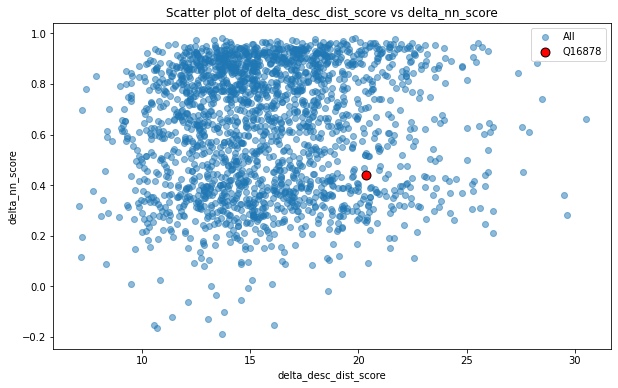

In [10]:
# Plot delta_nn_score ~ delta_desc_dist_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df_results['delta_desc_dist_score'], df_results['delta_nn_score'], alpha=0.5, label='All')

# Highlight the row(s) whose uniprot_accn is Q16878
highlight_mask = df_results['uniprot_accn'] == "Q16878"
if highlight_mask.any():
    plt.scatter(
        df_results.loc[highlight_mask, 'delta_desc_dist_score'],
        df_results.loc[highlight_mask, 'delta_nn_score'],
        color='red',
        s=80,
        edgecolor='black',
        label='Q16878'
    )

plt.xlabel('delta_desc_dist_score')
plt.ylabel('delta_nn_score')
plt.title('Scatter plot of delta_desc_dist_score vs delta_nn_score')
plt.legend()
plt.show()

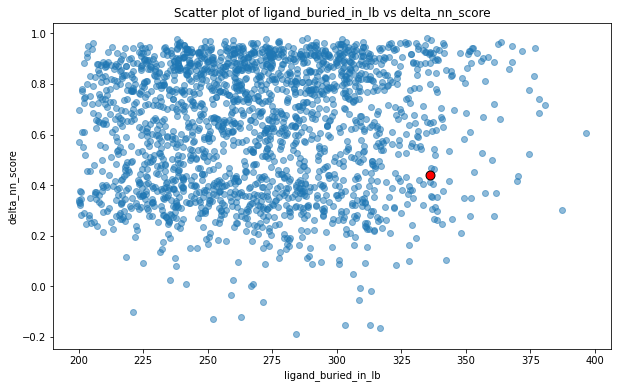

In [12]:
# Plot delta_nn_score ~ ligand_buried_in_lb


plt.figure(figsize=(10, 6))
plt.scatter(df_results['ligand_buried_in_lb'], df_results['delta_nn_score'], alpha=0.5)

# Highlight the row(s) whose uniprot_accn is Q16878
highlight_mask = df_results['uniprot_accn'] == "Q16878"
if highlight_mask.any():
    plt.scatter(
        df_results.loc[highlight_mask, 'ligand_buried_in_lb'],
        df_results.loc[highlight_mask, 'delta_nn_score'],
        color='red',
        s=80,
        edgecolor='black',
        label='Q16878'
    )
plt.xlabel('ligand_buried_in_lb')
plt.ylabel('delta_nn_score')
plt.title('Scatter plot of ligand_buried_in_lb vs delta_nn_score')
plt.show()


___
### Step 4 - SLURM script to parallelize the processing of unfiltered results .csv 

Unfiltered results.csv contains too many rows to be processed inside notebook even with parallelism. Run it on SLURM

In [4]:
# Directory to run SLURM jobs
slurm_dir = "/scratch/ymeng/masif-neosurf-af2/tricomplex-design_Meng/results/8VLB_A_3JF_A/ligand_delta_score"
slurm_input_dir = os.path.join(slurm_dir, "input")
slurm_output_dir = os.path.join(slurm_dir, "output")

# Create directories if they don't exist
os.makedirs(slurm_input_dir, exist_ok=True)
os.makedirs(slurm_output_dir, exist_ok=True)

# Number of SLURM jobs to run in parallel
n_jobs = 500

# Split all rows of the df_results into <n_jobs> .csv files (input_1.csv, input_2.csv, ...)
df_results_split = np.array_split(df_results, n_jobs)

for i, df_split in enumerate(df_results_split):
    input_file = os.path.join(slurm_input_dir, f"input_{i+1}.csv")
    df_split.to_csv(input_file, index=False)

/home/ymeng/miniconda3/envs/MaSIF/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [10]:
!sbatch --array 11-500 \
  --export=ALL,TARGET_PREPROC_DIR=/scratch/ymeng/masif-neosurf-af2/tricomplex-design_Meng/search_af2_grid/8VLB_A_3JF_A/preprocessing,MATCH_PREPROC_DIR=/work/lpdi/users/diazrovi/domaindome/20260221-AFDBv6_domaindome_DPAM_masif/dpam_domaindome_masif_db \
  /scratch/ymeng/masif-neosurf-af2/scripts/Meng/ligand_delta_score.sh \
  {slurm_input_dir} \
  {slurm_output_dir}

sbatch: [ESTIMATION] The estimated cost of this job is CHF 2.69
sbatch: ╭──────────────────────────────┬─────────────┬─────────────┬─────────────╮
sbatch: │ [in CHF]                     │ Capping     │ Consumed    │ Queued ¹⁾ ²⁾│
sbatch: ├──────────────────────────────┼─────────────┼─────────────┼─────────────┤
sbatch: │ username : ymeng             │ 0           │ 13.85       │ 2.7         │
sbatch: ├──────────────────────────────┼─────────────┼─────────────┼─────────────┤
sbatch: │ account : upthomae           │ 10,000      │ 14.6        │ 2.7         │
sbatch: ╰──────────────────────────────┴─────────────┴─────────────┴─────────────╯
sbatch: ¹⁾ Estimated cost of the queued jobs and this job
sbatch: ²⁾ Queued jobs costs are based on its walltime (option --time)
Submitted batch job 52397363


In [14]:
# -------- Load the output csv --------

# Remove too many extra columns written by the SLURM script
columns_to_remove = [
    "no_ligand_preprocessed_now",
    "rev_no_ligand_binder_iface_score",
    "rev_no_ligand_binder_name",
    "rev_no_ligand_binder_vix",
    "rev_no_ligand_desc_dist_score",
    "rev_no_ligand_descriptor_distance",
    "rev_no_ligand_distance_between_center_points",
    "rev_no_ligand_mean_desc_dist_score",
    "rev_no_ligand_nn_score",
    "rev_no_ligand_query_iface_score",
    "rev_no_ligand_query_name",
    "rev_no_ligand_query_site",
    "rev_no_ligand_query_vix",
    "rev_with_ligand_binder_iface_score",
    "rev_with_ligand_binder_name",
    "rev_with_ligand_binder_vix",
    "rev_with_ligand_desc_dist_score",
    "rev_with_ligand_descriptor_distance",
    "rev_with_ligand_distance_between_center_points",
    "rev_with_ligand_mean_desc_dist_score",
    "rev_with_ligand_nn_score",
    "rev_with_ligand_query_iface_score",
    "rev_with_ligand_query_name",
    "rev_with_ligand_query_site",
    "rev_with_ligand_query_vix",
    "target_no_ligand"
]

df_results_delta = pd.DataFrame()

for i in os.listdir(slurm_output_dir):
    if i.endswith(".csv") and "failed" not in i:
        df_i = pd.read_csv(os.path.join(slurm_output_dir, i))
        df_i = df_i.drop(columns=columns_to_remove)
        df_results_delta = pd.concat([df_results_delta, df_i])


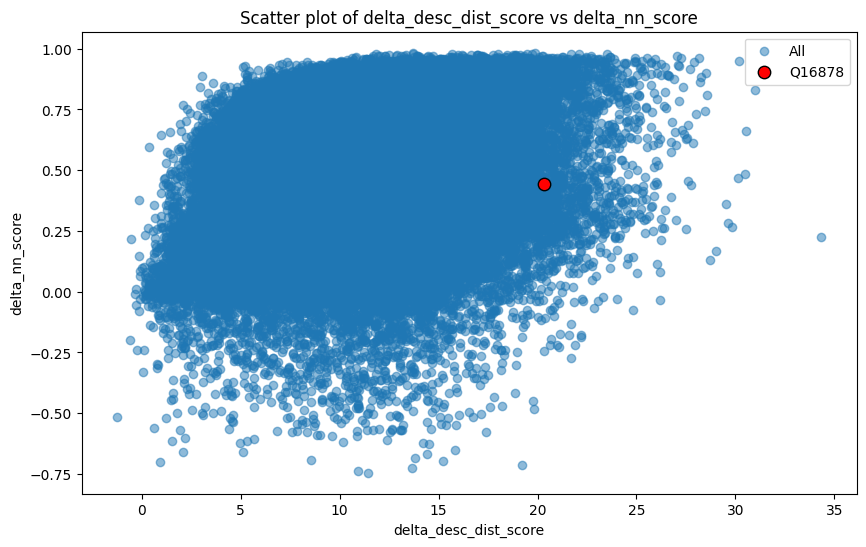

In [17]:
# Plot delta_nn_score ~ delta_desc_dist_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df_results_delta['delta_desc_dist_score'], df_results_delta['delta_nn_score'], alpha=0.5, label='All')

# Highlight the row(s) whose uniprot_accn is Q16878
highlight_mask = df_results_delta['uniprot_accn'] == "Q16878"
if highlight_mask.any():
    plt.scatter(
        df_results_delta.loc[highlight_mask, 'delta_desc_dist_score'],
        df_results_delta.loc[highlight_mask, 'delta_nn_score'],
        color='red',
        s=80,
        edgecolor='black',
        label='Q16878'
    )

plt.xlabel('delta_desc_dist_score')
plt.ylabel('delta_nn_score')
plt.title('Scatter plot of delta_desc_dist_score vs delta_nn_score')
plt.legend()
plt.show()

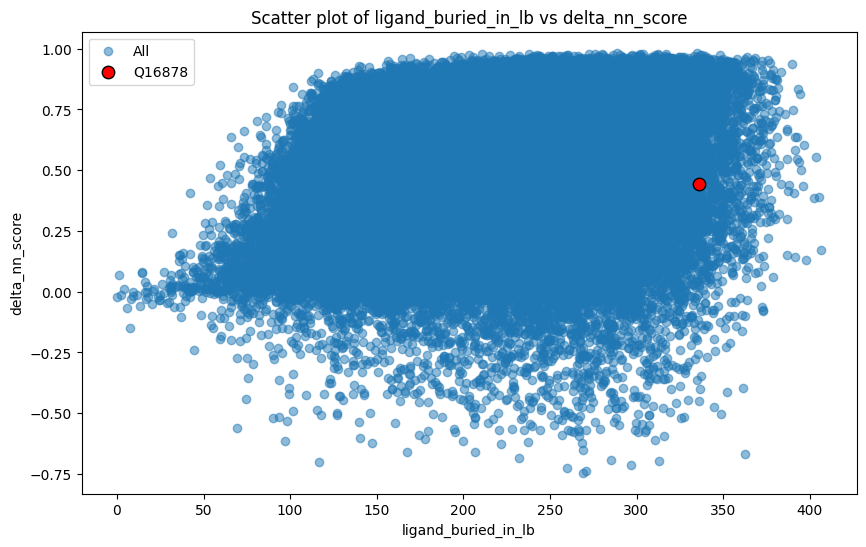

In [20]:
# Plot delta_nn_score ~ ligand_buried_in_lb
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df_results_delta['ligand_buried_in_lb'], df_results_delta['delta_nn_score'], alpha=0.5, label='All')

# Highlight the row(s) whose uniprot_accn is Q16878
highlight_mask = df_results_delta['uniprot_accn'] == "Q16878"
if highlight_mask.any():
    plt.scatter(
        df_results_delta.loc[highlight_mask, 'ligand_buried_in_lb'],
        df_results_delta.loc[highlight_mask, 'delta_nn_score'],
        color='red',
        s=80,
        edgecolor='black',
        label='Q16878'
    )

plt.xlabel('ligand_buried_in_lb')
plt.ylabel('delta_nn_score')
plt.title('Scatter plot of ligand_buried_in_lb vs delta_nn_score')
plt.legend()
plt.show()

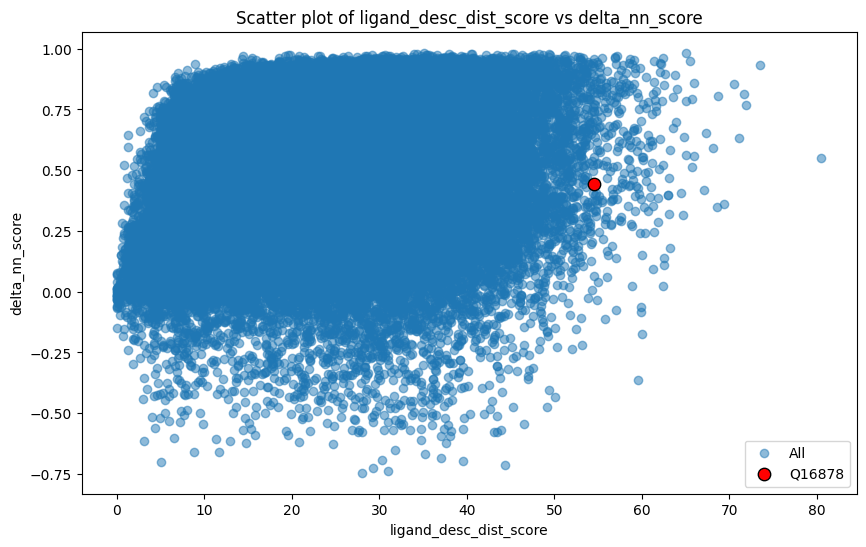

In [21]:
# Plot delta_nn_score ~ ligand_desc_dist_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df_results_delta['ligand_desc_dist_score'], df_results_delta['delta_nn_score'], alpha=0.5, label='All')

# Highlight the row(s) whose uniprot_accn is Q16878
highlight_mask = df_results_delta['uniprot_accn'] == "Q16878"
if highlight_mask.any():
    plt.scatter(
        df_results_delta.loc[highlight_mask, 'ligand_desc_dist_score'],
        df_results_delta.loc[highlight_mask, 'delta_nn_score'],
        color='red',
        s=80,
        edgecolor='black',
        label='Q16878'
    )

plt.xlabel('ligand_desc_dist_score')
plt.ylabel('delta_nn_score')
plt.title('Scatter plot of ligand_desc_dist_score vs delta_nn_score')
plt.legend()
plt.show()

In [23]:
# Write df_results_delta to csv
df_results_delta.to_csv(os.path.join(os.path.dirname(search_results_csv), str.replace(search_results_csv, ".csv", "_delta_scores.csv")), index=False)
